# Verify ISIMIP Data Processing for National Parks

This notebook visualizes the processed climate data to verify that the spatial subsetting is correct.

**Processing parameters:**

**Joshua Tree National Park (JOTR):**
- Longitude: -116.555° to -114.945°
- Latitude: 33.655° to 34.345°

**Mojave National Preserve (MOJAVE):**
- Longitude: -116.665° to -114.445°
- Latitude: 34.717° to 36.091°

**Common parameters:**
- Variable: Precipitation (pr)
- Scenario: Historical
- Expected time range: 1850-2014 (monthly data)

In [8]:
# Import required libraries
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
import numpy as np

In [9]:
# Define paths and regions
data_dir = Path('data/processed')

regions = {
    'jotr': {
        'name': 'Joshua Tree National Park',
        'shapefile': Path('data/Joshua_Tree_National_Park.shp'),
        'pattern': '*_jotr_monthly.nc',
        'bounds': {'lonmin': -116.555, 'lonmax': -114.945, 'latmin': 33.655, 'latmax': 34.345}
    },
    'mojave': {
        'name': 'Mojave National Preserve',
        'shapefile': Path('data/Mojave_National_Preserve.shp'),
        'pattern': '*_mojave_monthly.nc',
        'bounds': {'lonmin': -116.665, 'lonmax': -114.445, 'latmin': 34.717, 'latmax': 36.091}
    }
}

# Load shapefiles and list processed files
for region_id, region_info in regions.items():
    region_info['gdf'] = gpd.read_file(region_info['shapefile'])
    region_info['files'] = sorted(data_dir.glob(region_info['pattern']))
    print(f"\n{region_info['name']}:")
    print(f"  Found {len(region_info['files'])} processed files")
    print(f"  Shapefile bounds: {region_info['gdf'].total_bounds}")


Joshua Tree National Park:
  Found 1 processed files
  Shapefile bounds: [-116.4580428    33.67019079 -115.26220226   34.12934798]

Mojave National Preserve:
  Found 1 processed files
  Shapefile bounds: [-116.16503149   34.71693111 -114.94915818   35.59077465]


In [10]:
# Verify time steps and spatial coverage for all files
print("="*80)
print("DATA VERIFICATION SUMMARY")
print("="*80)

expected_months = 165 * 12  # 1850-2014: 165 years * 12 months = 1980 months

for region_id, region_info in regions.items():
    print(f"\n{region_info['name'].upper()}")
    print("-" * 80)
    
    if len(region_info['files']) == 0:
        print("  ⚠ No processed files found!")
        continue
    
    for file in region_info['files']:
        ds = xr.open_dataset(file)
        model_name = file.name.split('_')[0]
        
        # Check spatial extent
        lon_ok = (float(ds.lon.min()) >= region_info['bounds']['lonmin'] - 0.5 and 
                  float(ds.lon.max()) <= region_info['bounds']['lonmax'] + 0.5)
        lat_ok = (float(ds.lat.min()) >= region_info['bounds']['latmin'] - 0.5 and 
                  float(ds.lat.max()) <= region_info['bounds']['latmax'] + 0.5)
        
        # Check time steps
        time_ok = len(ds.time) == expected_months
        
        # Status indicators
        spatial_status = "✓" if (lon_ok and lat_ok) else "✗"
        time_status = "✓" if time_ok else "✗"
        
        print(f"\n  {model_name}:")
        print(f"    Spatial extent {spatial_status}: lon=[{float(ds.lon.min()):.3f}, {float(ds.lon.max()):.3f}], "
              f"lat=[{float(ds.lat.min()):.3f}, {float(ds.lat.max()):.3f}]")
        print(f"    Time steps {time_status}: {len(ds.time)} months (expected: {expected_months})")
        print(f"    Time range: {ds.time.min().dt.strftime('%Y-%m').values} to {ds.time.max().dt.strftime('%Y-%m').values}")
        print(f"    Grid shape: {ds.pr.shape}")
        
        ds.close()

print("\n" + "="*80)

DATA VERIFICATION SUMMARY

JOSHUA TREE NATIONAL PARK
--------------------------------------------------------------------------------

  ukesm1-0-ll:
    Spatial extent ✓: lon=[-116.250, -115.250], lat=[33.750, 34.250]
    Time steps ✓: 1980 months (expected: 1980)
    Time range: 1850-01 to 2014-12
    Grid shape: (1980, 2, 3)

MOJAVE NATIONAL PRESERVE
--------------------------------------------------------------------------------

  ukesm1-0-ll:
    Spatial extent ✓: lon=[-116.250, -114.750], lat=[34.750, 35.750]
    Time steps ✓: 1980 months (expected: 1980)
    Time range: 1850-01 to 2014-12
    Grid shape: (1980, 3, 4)



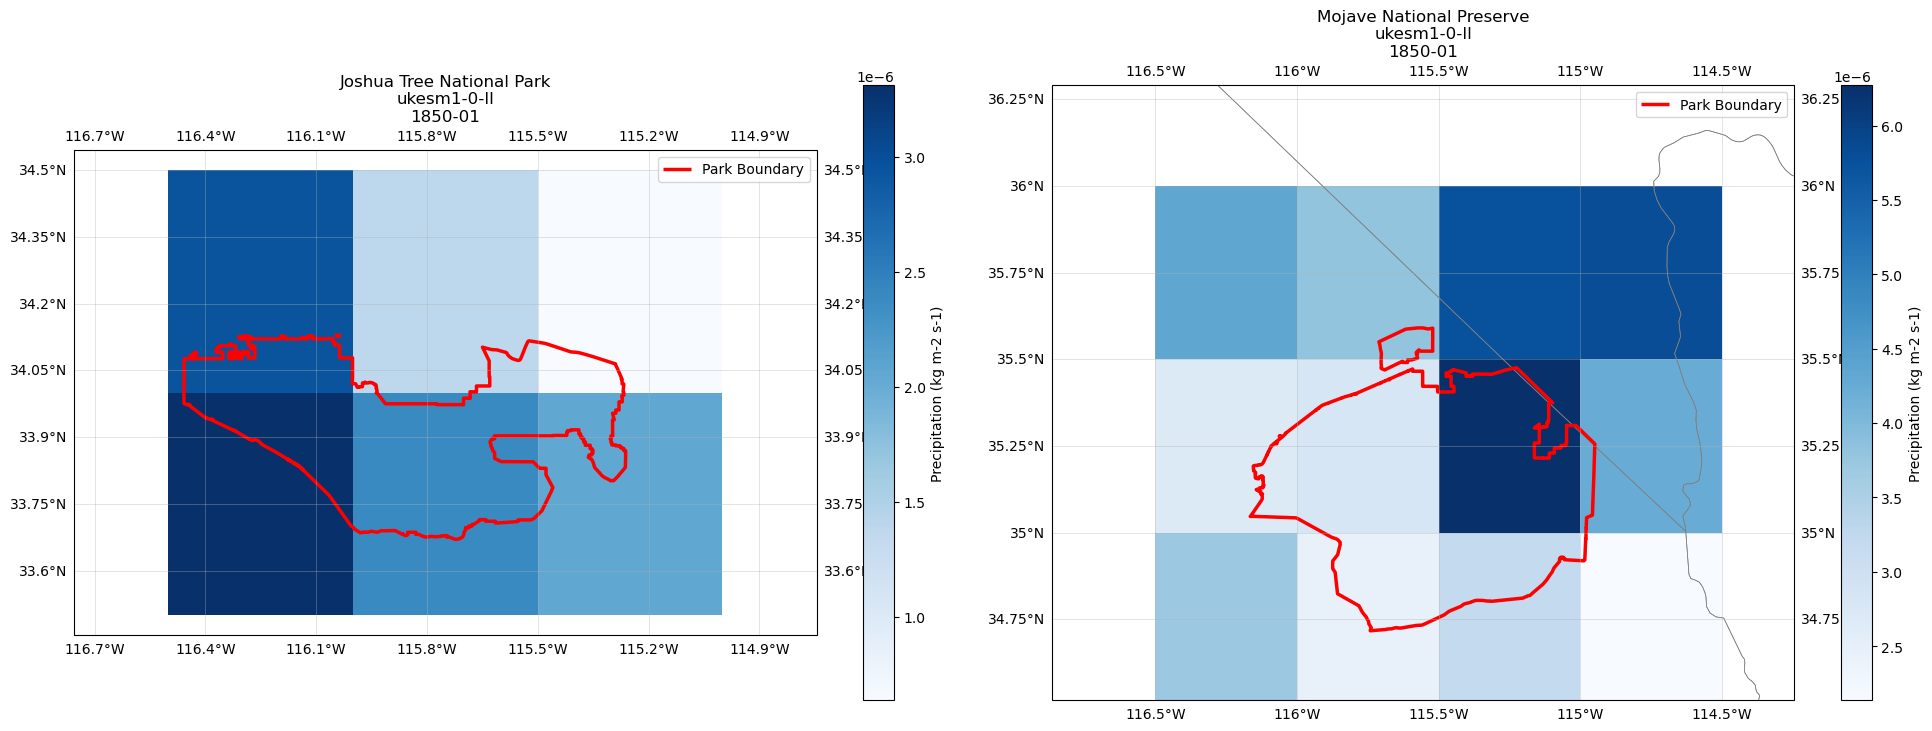

In [11]:
# Plot side-by-side maps for both parks
fig, axes = plt.subplots(1, 2, figsize=(20, 8), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

for idx, (region_id, region_info) in enumerate(regions.items()):
    if len(region_info['files']) == 0:
        continue
        
    ax = axes[idx]
    
    # Load first file and first time step
    ds = xr.open_dataset(region_info['files'][0])
    data_slice = ds.pr.isel(time=0)
    
    # Plot the data
    im = data_slice.plot(ax=ax, transform=ccrs.PlateCarree(), 
                         cmap='Blues', add_colorbar=True,
                         cbar_kwargs={'label': 'Precipitation (kg m-2 s-1)', 'shrink': 0.8})
    
    # Overlay the shapefile
    region_info['gdf'].boundary.plot(ax=ax, color='red', linewidth=2.5, label='Park Boundary')
    
    # Add features
    ax.coastlines(resolution='10m', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
    
    # Set extent
    bounds = region_info['bounds']
    ax.set_extent([bounds['lonmin'] - 0.2, bounds['lonmax'] + 0.2,
                   bounds['latmin'] - 0.2, bounds['latmax'] + 0.2], 
                  crs=ccrs.PlateCarree())
    
    ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    ax.set_title(f"{region_info['name']}\n{region_info['files'][0].name.split('_')[0]}\n{data_slice.time.dt.strftime('%Y-%m').values}", 
                 fontsize=12)
    ax.legend(loc='upper right')
    
    ds.close()

plt.tight_layout()
plt.show()

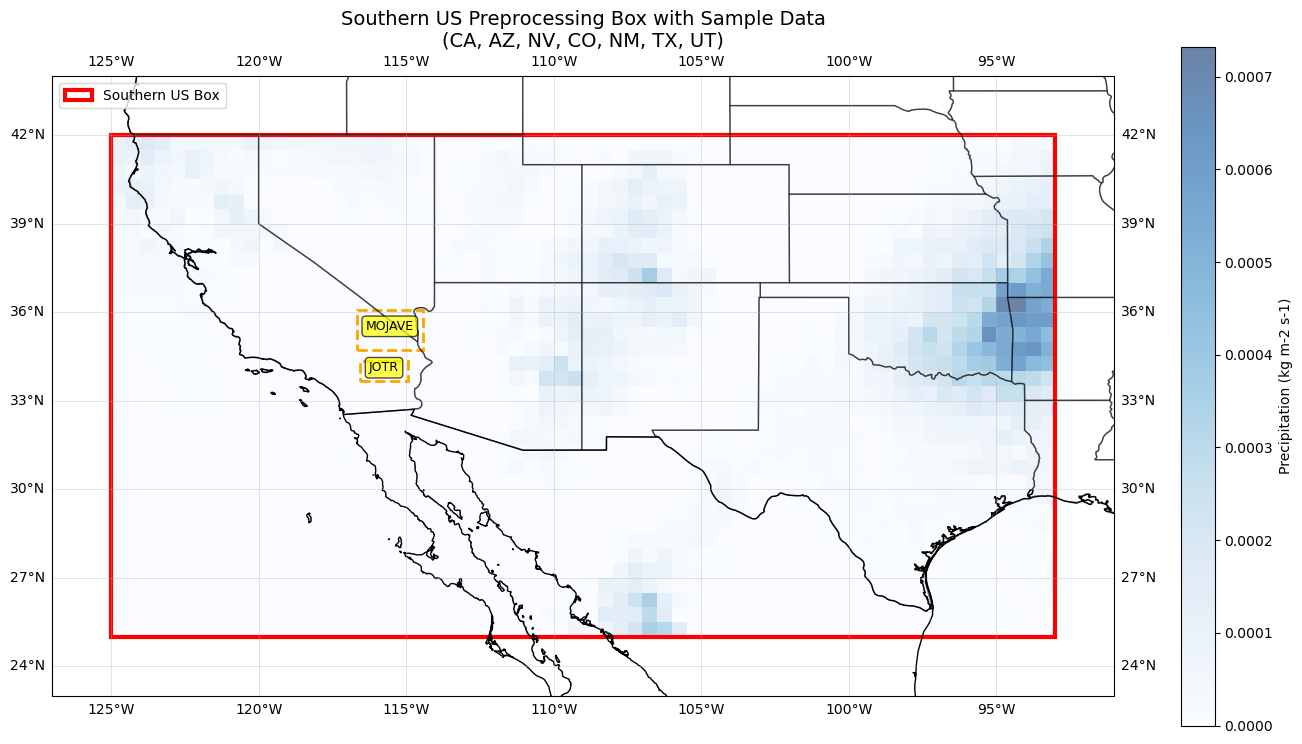

In [13]:
# Diagnostic: Verify Southern US bounding box with data
fig, ax = plt.subplots(figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Southern US bounding box from preprocessing
southus_bounds = {
    'lonmin': -125.0,
    'lonmax': -93.0,
    'latmin': 25.0,
    'latmax': 42.0
}

# Load and plot a sample interim file to verify coverage
interim_files = sorted(Path('data/interim').glob('*_southus_daily_*.nc'))
if len(interim_files) > 0:
    sample_interim = xr.open_dataset(interim_files[0])
    # Plot first timestep
    data_slice = sample_interim.pr.isel(time=0)
    data_slice.plot(ax=ax, transform=ccrs.PlateCarree(), 
                    cmap='Blues', add_colorbar=True,
                    cbar_kwargs={'label': 'Precipitation (kg m-2 s-1)', 'shrink': 0.7},
                    alpha=0.6)
    sample_interim.close()

# Add map features
ax.coastlines(resolution='10m', linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=1)
ax.add_feature(cfeature.STATES, linewidth=1, edgecolor='black', alpha=0.5)

# Draw Southern US bounding box
from matplotlib.patches import Rectangle
rect = Rectangle((southus_bounds['lonmin'], southus_bounds['latmin']),
                 southus_bounds['lonmax'] - southus_bounds['lonmin'],
                 southus_bounds['latmax'] - southus_bounds['latmin'],
                 linewidth=3, edgecolor='red', facecolor='none',
                 transform=ccrs.PlateCarree(), label='Southern US Box')
ax.add_patch(rect)

# Draw JOTR and Mojave boxes
for region_id, region_info in regions.items():
    bounds = region_info['bounds']
    rect = Rectangle((bounds['lonmin'], bounds['latmin']),
                     bounds['lonmax'] - bounds['lonmin'],
                     bounds['latmax'] - bounds['latmin'],
                     linewidth=2, edgecolor='orange', facecolor='none',
                     linestyle='--',
                     transform=ccrs.PlateCarree())
    ax.add_patch(rect)
    # Add label
    center_lon = (bounds['lonmin'] + bounds['lonmax']) / 2
    center_lat = (bounds['latmin'] + bounds['latmax']) / 2
    ax.text(center_lon, center_lat, region_id.upper(), 
            transform=ccrs.PlateCarree(), fontsize=9, ha='center',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

# Set extent to show the full Southern US region
ax.set_extent([southus_bounds['lonmin'] - 2, southus_bounds['lonmax'] + 2,
               southus_bounds['latmin'] - 2, southus_bounds['latmax'] + 2], 
              crs=ccrs.PlateCarree())

ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
ax.set_title('Southern US Preprocessing Box with Sample Data\n(CA, AZ, NV, CO, NM, TX, UT)', fontsize=14)
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [14]:
print("\n" + "="*80)
print("✓ VERIFICATION COMPLETE")
print("="*80)
print("\nAll datasets have been checked for:")
print("  • Correct spatial coverage (within park boundaries)")
print("  • Complete time series (1850-2014, 1980 months)")
print("  • Valid data values")


✓ VERIFICATION COMPLETE

All datasets have been checked for:
  • Correct spatial coverage (within park boundaries)
  • Complete time series (1850-2014, 1980 months)
  • Valid data values
